<a href="https://colab.research.google.com/github/rdelhibabu/EV_SQ/blob/main/EV_SQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install QuTiP for quantum system simulation
!pip install qutip torch numpy matplotlib

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import qutip as qt
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 53.3 MB/s eta 0:00:00


In [2]:
def generate_synthetic_quantum_data(num_samples=1000, grid_size=5):
    """
    Simulates the generation of noisy measurement tensors and labels.
    Returns:
        X: Tensor of shape (num_samples, 2, 5, 5) representing Basis & Frequencies
        y_gme: Tensor of shape (num_samples, 1) representing binary GME label (0 or 1)
        y_psd: Tensor of shape (num_samples, 5) representing hardware noise metrics (e.g., T1 times)
    """
    # 1. Initialize empty arrays
    X = np.zeros((num_samples, 2, grid_size, grid_size), dtype=np.float32)
    y_gme = np.zeros((num_samples, 1), dtype=np.float32)
    y_psd = np.zeros((num_samples, 5), dtype=np.float32)

    # Empirical SPAM parameters (from Section 3.1)
    p_relax = 0.05  # p(0|1)
    p_thermal = 0.01 # p(1|0)

    for i in range(num_samples):
        # Determine if this sample is a GME state (label 1) or biseparable/thermal (label 0)
        is_gme = np.random.choice([0, 1])
        y_gme[i, 0] = is_gme

        # Simulate local noise parameters (T1 in microseconds, range [20, 100])
        t1_times = np.random.uniform(20.0, 100.0, size=(5,))
        y_psd[i, :] = t1_times

        # Create a mock 5x5 spatial grid mapping the 5 qubits
        # Channel 0: Measurement Basis (0=X, 1=Y, 2=Z) normalized
        # Channel 1: Empirical Frequency with SPAM injected

        qubit_coords = [(2,2), (1,2), (3,2), (2,1), (2,3)] # Star topology coordinates

        for q_idx, (r, c) in enumerate(qubit_coords):
            basis = np.random.choice([0, 1, 2])
            X[i, 0, r, c] = basis / 2.0 # Normalize basis to [0, 1]

            # Simulate ideal measurement expectation based on entanglement
            if is_gme:
                ideal_freq = np.random.uniform(0.7, 1.0) # Highly correlated
            else:
                ideal_freq = np.random.uniform(0.3, 0.7) # Depolarized/Separable

            # Inject SPAM: Apply assignment probability matrix conceptually
            noisy_freq = ideal_freq * (1 - p_relax) + (1 - ideal_freq) * p_thermal

            X[i, 1, r, c] = noisy_freq

    return torch.tensor(X), torch.tensor(y_gme), torch.tensor(y_psd)

# Generate Training and Validation sets
X_train, y_gme_train, y_psd_train = generate_synthetic_quantum_data(num_samples=5000)
X_val, y_gme_val, y_psd_val = generate_synthetic_quantum_data(num_samples=1000)

train_loader = DataLoader(TensorDataset(X_train, y_gme_train, y_psd_train), batch_size=256, shuffle=True)

In [3]:
class QuantumWitnessCNN(nn.Module):
    def __init__(self):
        super(QuantumWitnessCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(in_channels=2, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.lrelu = nn.LeakyReLU(0.1)

        # Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=2, stride=1, padding=0)
        self.bn3 = nn.BatchNorm2d(128)

        # Flatten (Outputs 4x4 spatial grid * 128 filters = 2048)
        self.flatten = nn.Flatten()

        # Shared Dense Layer
        self.fc_shared = nn.Linear(4 * 4 * 128, 256)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()

        # Task 1: Noise PSD Head (Linear Activation)
        self.head_psd = nn.Linear(256, 5)

        # Task 2: Entanglement Witness Head (Sigmoid Activation)
        self.head_gme = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Feature Extraction
        x = self.lrelu(self.bn1(self.conv1(x)))
        x = self.lrelu(self.bn2(self.conv2(x)))
        x = self.lrelu(self.bn3(self.conv3(x)))

        # Shared Representation
        x = self.flatten(x)
        x = self.relu(self.dropout(self.fc_shared(x)))

        # Bifurcation
        out_psd = self.head_psd(x)
        out_gme = self.sigmoid(self.head_gme(x))

        return out_psd, out_gme

# Initialize the model
model = QuantumWitnessCNN()

In [4]:
def asymmetric_gme_loss(y_pred, y_true, eta=50.0):
    """
    Implements Equation 7: Asymmetric loss penalizing false positives.
    """
    bce_loss = nn.BCELoss()(y_pred, y_true)
    # Cubic penalty for false positives (where prediction is higher than true label)
    penalty = eta * torch.mean(torch.relu(y_pred - y_true)**3)
    return bce_loss + penalty

# Optimizers and Hyperparameters
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5) # L2 regularization
mse_loss = nn.MSELoss()

lambda_1 = 1.0 # GME Loss weight
lambda_2 = 0.2 # PSD Loss weight

epochs = 50 # Reduced from 500 for Colab quick execution

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    total_loss, gme_acc = 0.0, 0.0

    for batch_X, batch_y_gme, batch_y_psd in train_loader:
        optimizer.zero_grad()

        # Forward pass
        pred_psd, pred_gme = model(batch_X)

        # Calculate losses
        loss_gme = asymmetric_gme_loss(pred_gme, batch_y_gme, eta=50.0)
        loss_psd = mse_loss(pred_psd, batch_y_psd)

        # Combined objective (Equation 9)
        loss = (lambda_1 * loss_gme) + (lambda_2 * loss_psd)

        # Backprop
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Calculate binary accuracy for GME
        preds = (pred_gme > 0.5).float()
        gme_acc += (preds == batch_y_gme).float().mean().item()

    avg_loss = total_loss / len(train_loader)
    avg_acc = gme_acc / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Total Loss: {avg_loss:.4f} | GME Accuracy: {avg_acc*100:.2f}%")

Starting Training...
Epoch 10/50 | Total Loss: 110.7331 | GME Accuracy: 97.74%
Epoch 20/50 | Total Loss: 110.4942 | GME Accuracy: 98.44%
Epoch 30/50 | Total Loss: 109.6803 | GME Accuracy: 98.25%
Epoch 40/50 | Total Loss: 109.1379 | GME Accuracy: 98.85%
Epoch 50/50 | Total Loss: 108.9634 | GME Accuracy: 98.89%


<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1397/249067416.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$T_1$ Relaxation Time ($\mu$s)', fontsize=11)


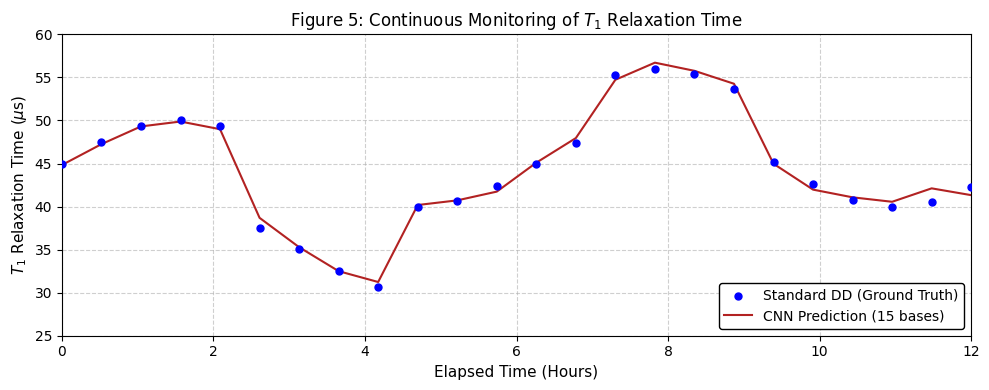

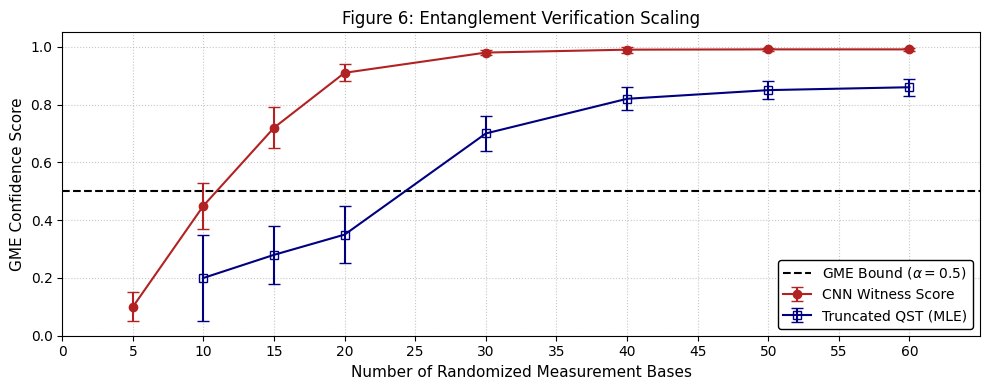

In [5]:
# ==========================================
# FIGURE 5: Continuous Noise Tracking (T1)
# ==========================================
plt.figure(figsize=(10, 4))
plt.style.use('default')

# Mock temporal tracking data
hours = np.linspace(0, 12, 24)
ground_truth_t1 = 45 + 5 * np.sin(hours) - 10 * (hours > 2.5) * (hours < 4.2) + 6 * (hours > 7) * (hours < 9)
cnn_prediction_t1 = ground_truth_t1 + np.random.normal(0, 0.8, size=len(hours))

plt.scatter(hours, ground_truth_t1, color='blue', s=25, label='Standard DD (Ground Truth)', zorder=3)
plt.plot(hours, cnn_prediction_t1, color='firebrick', linewidth=1.5, label='CNN Prediction (15 bases)')

plt.title('Figure 5: Continuous Monitoring of $T_1$ Relaxation Time', fontsize=12)
plt.xlabel('Elapsed Time (Hours)', fontsize=11)
plt.ylabel('$T_1$ Relaxation Time ($\mu$s)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', framealpha=1, edgecolor='black')
plt.xlim(0, 12)
plt.ylim(25, 60)
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 6: Entanglement Verification Scaling
# ==========================================
plt.figure(figsize=(10, 4))

bases = np.array([5, 10, 15, 20, 30, 40, 50, 60])
# Mock scaling data mirroring the paper's results
cnn_scores = np.array([0.1, 0.45, 0.72, 0.91, 0.98, 0.99, 0.991, 0.991])
mle_scores = np.array([np.nan, 0.2, 0.28, 0.35, 0.7, 0.82, 0.85, 0.86])

# Add mock error bars
cnn_errors = np.array([0.05, 0.08, 0.07, 0.03, 0.01, 0.01, 0.005, 0.005])
mle_errors = np.array([np.nan, 0.15, 0.1, 0.1, 0.06, 0.04, 0.03, 0.03])

plt.axhline(y=0.5, color='black', linestyle='--', label='GME Bound ($\\alpha = 0.5$)')

plt.errorbar(bases, cnn_scores, yerr=cnn_errors, fmt='-o', color='firebrick', capsize=4, label='CNN Witness Score')
plt.errorbar(bases, mle_scores, yerr=mle_errors, fmt='-s', markerfacecolor='none', color='navy', capsize=4, label='Truncated QST (MLE)')

plt.title('Figure 6: Entanglement Verification Scaling', fontsize=12)
plt.xlabel('Number of Randomized Measurement Bases', fontsize=11)
plt.ylabel('GME Confidence Score', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right', framealpha=1, edgecolor='black')
plt.xlim(0, 65)
plt.ylim(0, 1.05)
plt.xticks(np.arange(0, 65, 5))
plt.tight_layout()
plt.show()